In [1]:
import tensorflow as tf

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.layers.core import SpatialDropout2D
from keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image

import matplotlib.pyplot as plt
import cv2
%matplotlib inline
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications.inception_v3 import InceptionV3
# from tensorflow.keras import layersfrom keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
from keras.models import load_model
import itertools 
filterwarnings('ignore')
np.random.seed(101)
from sklearn.metrics import classification_report, confusion_matrix
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
import glob
from PIL import Image


from tensorflow.keras.mixed_precision import experimental as mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)


In [4]:
train_dir ="train"
val_dir = "val"
test_dir="test"


In [5]:
model1 = InceptionV3(include_top=False,input_shape=(224, 224,3), weights='imagenet')
input_shape = (224, 224)

In [6]:
datagen_train = ImageDataGenerator(rescale=1./255,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  horizontal_flip=True,
                                  vertical_flip=False)



datagen_test = ImageDataGenerator(rescale=1./255)

datagen_val=ImageDataGenerator(rescale=1./255)

batch_size = 20
generator_train = datagen_train.flow_from_directory(directory=train_dir,
                                                    target_size=input_shape,
                                                    batch_size=batch_size,  
                                                    class_mode='categorical',
                                                    shuffle=True)

generator_val = datagen_val.flow_from_directory(directory=val_dir,
                                                  target_size=input_shape,
                                                  batch_size=batch_size,
                                                class_mode='categorical',
                                                  shuffle=True)
generator_test=datagen_test.flow_from_directory(directory=test_dir,
                                                  target_size=input_shape,
                                                 batch_size=batch_size,
                                                class_mode='categorical',
                                                 shuffle=False)

Found 3248 images belonging to 4 classes.
Found 409 images belonging to 4 classes.
Found 405 images belonging to 4 classes.


In [7]:
len(model1.layers)

311

In [8]:
def print_layer_trainable():
    for layer in model1.layers[:-1]:
        layer.trainable=False
        print("{0}:\t{1}".format(layer.trainable, layer.name))


print_layer_trainable()

False:	input_1
False:	conv2d
False:	batch_normalization
False:	activation
False:	conv2d_1
False:	batch_normalization_1
False:	activation_1
False:	conv2d_2
False:	batch_normalization_2
False:	activation_2
False:	max_pooling2d
False:	conv2d_3
False:	batch_normalization_3
False:	activation_3
False:	conv2d_4
False:	batch_normalization_4
False:	activation_4
False:	max_pooling2d_1
False:	conv2d_8
False:	batch_normalization_8
False:	activation_8
False:	conv2d_6
False:	conv2d_9
False:	batch_normalization_6
False:	batch_normalization_9
False:	activation_6
False:	activation_9
False:	average_pooling2d
False:	conv2d_5
False:	conv2d_7
False:	conv2d_10
False:	conv2d_11
False:	batch_normalization_5
False:	batch_normalization_7
False:	batch_normalization_10
False:	batch_normalization_11
False:	activation_5
False:	activation_7
False:	activation_10
False:	activation_11
False:	mixed0
False:	conv2d_15
False:	batch_normalization_15
False:	activation_15
False:	conv2d_13
False:	conv2d_16
False:	batch_normali

In [10]:
from tensorflow.keras import layers 
headModel = model1.output
headModel = layers.Flatten()(headModel)
# headModel = Dense(1024, activation="relu")(headModel)
headModel = Dense(512, activation="relu")(headModel)
headModel = Dropout(0.4)(headModel)
headModel = Dense(4, activation="softmax")(headModel)
model = Model(inputs=model1.input, outputs=headModel)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                             

 batch_normalization_5 (BatchNo  (None, 25, 25, 64)  192         ['conv2d_5[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 batch_normalization_7 (BatchNo  (None, 25, 25, 64)  192         ['conv2d_7[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 batch_normalization_10 (BatchN  (None, 25, 25, 96)  288         ['conv2d_10[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_11 (BatchN  (None, 25, 25, 32)  96          ['conv2d_11[0][0]']              
 ormalizat

                                                                                                  
 batch_normalization_22 (BatchN  (None, 25, 25, 64)  192         ['conv2d_22[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_22 (Activation)     (None, 25, 25, 64)   0           ['batch_normalization_22[0][0]'] 
                                                                                                  
 conv2d_20 (Conv2D)             (None, 25, 25, 48)   13824       ['mixed1[0][0]']                 
                                                                                                  
 conv2d_23 (Conv2D)             (None, 25, 25, 96)   55296       ['activation_22[0][0]']          
                                                                                                  
 batch_nor

                                                                                                  
 max_pooling2d_2 (MaxPooling2D)  (None, 12, 12, 288)  0          ['mixed2[0][0]']                 
                                                                                                  
 mixed3 (Concatenate)           (None, 12, 12, 768)  0           ['activation_26[0][0]',          
                                                                  'activation_29[0][0]',          
                                                                  'max_pooling2d_2[0][0]']        
                                                                                                  
 conv2d_34 (Conv2D)             (None, 12, 12, 128)  98304       ['mixed3[0][0]']                 
                                                                                                  
 batch_normalization_34 (BatchN  (None, 12, 12, 128)  384        ['conv2d_34[0][0]']              
 ormalizat

                                                                  'activation_39[0][0]']          
                                                                                                  
 conv2d_44 (Conv2D)             (None, 12, 12, 160)  122880      ['mixed4[0][0]']                 
                                                                                                  
 batch_normalization_44 (BatchN  (None, 12, 12, 160)  480        ['conv2d_44[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_44 (Activation)     (None, 12, 12, 160)  0           ['batch_normalization_44[0][0]'] 
                                                                                                  
 conv2d_45 (Conv2D)             (None, 12, 12, 160)  179200      ['activation_44[0][0]']          
          

 ormalization)                                                                                    
                                                                                                  
 activation_54 (Activation)     (None, 12, 12, 160)  0           ['batch_normalization_54[0][0]'] 
                                                                                                  
 conv2d_55 (Conv2D)             (None, 12, 12, 160)  179200      ['activation_54[0][0]']          
                                                                                                  
 batch_normalization_55 (BatchN  (None, 12, 12, 160)  480        ['conv2d_55[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_55 (Activation)     (None, 12, 12, 160)  0           ['batch_normalization_55[0][0]'] 
          

                                                                                                  
 batch_normalization_65 (BatchN  (None, 12, 12, 192)  576        ['conv2d_65[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_65 (Activation)     (None, 12, 12, 192)  0           ['batch_normalization_65[0][0]'] 
                                                                                                  
 conv2d_61 (Conv2D)             (None, 12, 12, 192)  147456      ['mixed6[0][0]']                 
                                                                                                  
 conv2d_66 (Conv2D)             (None, 12, 12, 192)  258048      ['activation_65[0][0]']          
                                                                                                  
 batch_nor

                                                                                                  
 conv2d_70 (Conv2D)             (None, 12, 12, 192)  147456      ['mixed7[0][0]']                 
                                                                                                  
 conv2d_74 (Conv2D)             (None, 12, 12, 192)  258048      ['activation_73[0][0]']          
                                                                                                  
 batch_normalization_70 (BatchN  (None, 12, 12, 192)  576        ['conv2d_70[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_74 (BatchN  (None, 12, 12, 192)  576        ['conv2d_74[0][0]']              
 ormalization)                                                                                    
          

 batch_normalization_76 (BatchN  (None, 5, 5, 320)   960         ['conv2d_76[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_78 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_78[0][0]'] 
                                                                                                  
 activation_79 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_79[0][0]'] 
                                                                                                  
 activation_82 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_82[0][0]'] 
                                                                                                  
 activation_83 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_83[0][0]'] 
          

                                                                                                  
 activation_91 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_91[0][0]'] 
                                                                                                  
 activation_92 (Activation)     (None, 5, 5, 384)    0           ['batch_normalization_92[0][0]'] 
                                                                                                  
 batch_normalization_93 (BatchN  (None, 5, 5, 192)   576         ['conv2d_93[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_85 (Activation)     (None, 5, 5, 320)    0           ['batch_normalization_85[0][0]'] 
                                                                                                  
 mixed9_1 

In [11]:
optimizer = Adam(lr=1e-4)
loss = 'categorical_crossentropy'
metrics = ['accuracy','Precision','Recall']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [12]:

epochs = 25

steps_per_epoch = generator_train.n / batch_size
steps_test = generator_test.n / batch_size

# steps_per_epoch = 50
# steps_test = 50
early_stop = EarlyStopping(patience=2)
history = model.fit_generator(generator=generator_train,
                              epochs=epochs,
                              steps_per_epoch=steps_per_epoch,
                              validation_data=generator_val,
                              validation_steps=steps_test
                            
                             )

Epoch 1/25
162/162 [==============================] - 32s 166ms/step - loss: 0.6695 - accuracy: 0.8433 - precision: 0.8498 - recall: 0.8381 - val_loss: 0.1099 - val_accuracy: 0.9658 - val_precision: 0.9679 - val_recall: 0.9584
Epoch 2/25
162/162 [==============================] - 21s 129ms/step - loss: 0.1824 - accuracy: 0.9344 - precision: 0.9388 - recall: 0.9298 - val_loss: 0.1204 - val_accuracy: 0.9560 - val_precision: 0.9559 - val_recall: 0.9535
Epoch 3/25
162/162 [==============================] - 21s 131ms/step - loss: 0.1519 - accuracy: 0.9440 - precision: 0.9471 - recall: 0.9418 - val_loss: 0.1181 - val_accuracy: 0.9511 - val_precision: 0.9511 - val_recall: 0.9511
Epoch 4/25
162/162 [==============================] - 23s 139ms/step - loss: 0.1266 - accuracy: 0.9529 - precision: 0.9538 - recall: 0.9526 - val_loss: 0.0999 - val_accuracy: 0.9633 - val_precision: 0.9657 - val_recall: 0.9633
Epoch 5/25
162/162 [==============================] - 22s 138ms/step - loss: 0.1277 - accura

In [13]:
classes=list(generator_train.class_indices.keys())
class_count=len(classes)
print(class_count)

4


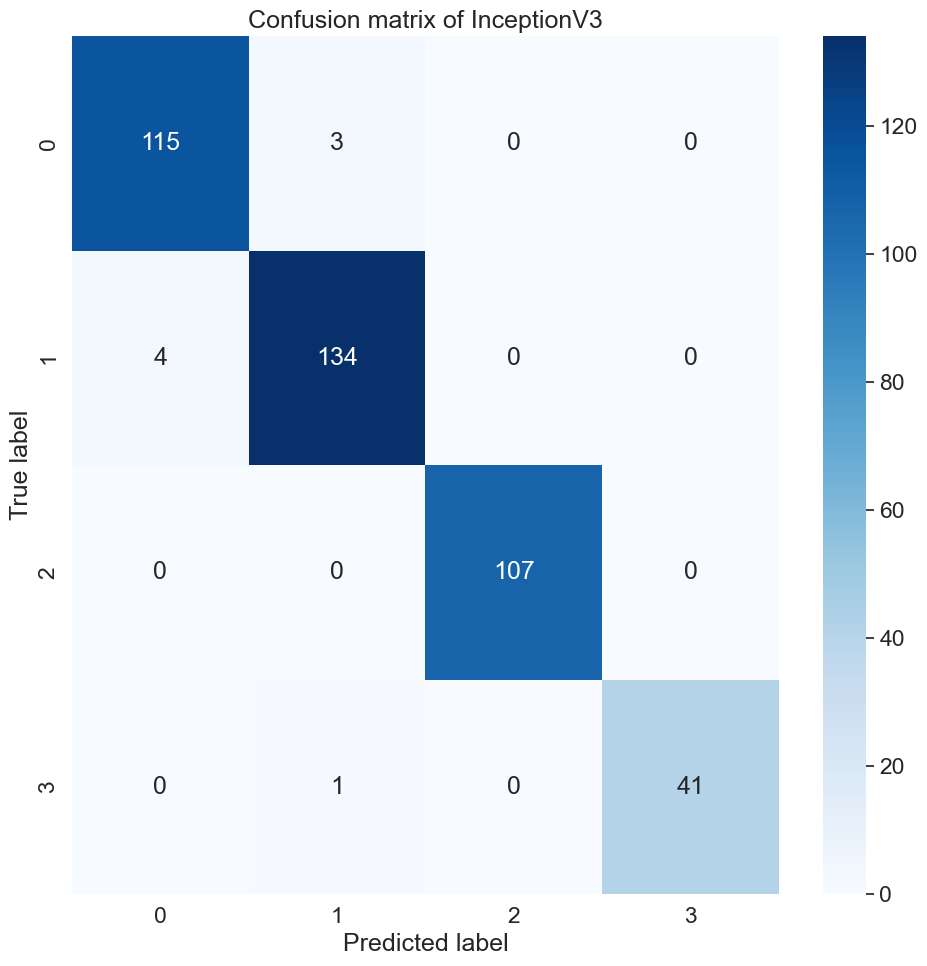

In [30]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Y_pred = model.predict_generator(generator_test)
y_pred = np.argmax(Y_pred, axis=1)
array = confusion_matrix(generator_test.classes, y_pred)
df_cm = pd.DataFrame(array, index =(i for i in range(0,4)),
                  columns = (i for i in range(0,4)))
plt.figure(figsize=(10,10))
sn.set(font_scale=1.5)
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix of InceptionV3')
plt.tight_layout()
plt.savefig('Confusion matrix of InceptionV3',dpi=200); 
plt.show()

In [31]:
model.save("InceptionV3.h5")

In [32]:
#Get the accuracy score

train_score = model.evaluate_generator(generator_train)



print("[INFO] accuracy: {:.2f}%".format(train_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(train_score[0] * 100)) 

[INFO] accuracy: 98.89%
[INFO] Loss: 3.04%


In [33]:
#Get the accuracy score

test_score = model.evaluate_generator(generator_test)



print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(test_score[0] * 100)) 
test_score

[INFO] accuracy: 98.02%
[INFO] Loss: 4.90%


[0.04902074858546257, 0.980246901512146, 0.980246901512146, 0.980246901512146]

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(generator_test.classes, y_pred)

0.980246913580247

In [35]:
target_names = []

for key in generator_train.class_indices:

    target_names.append(key)



print(target_names)

['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


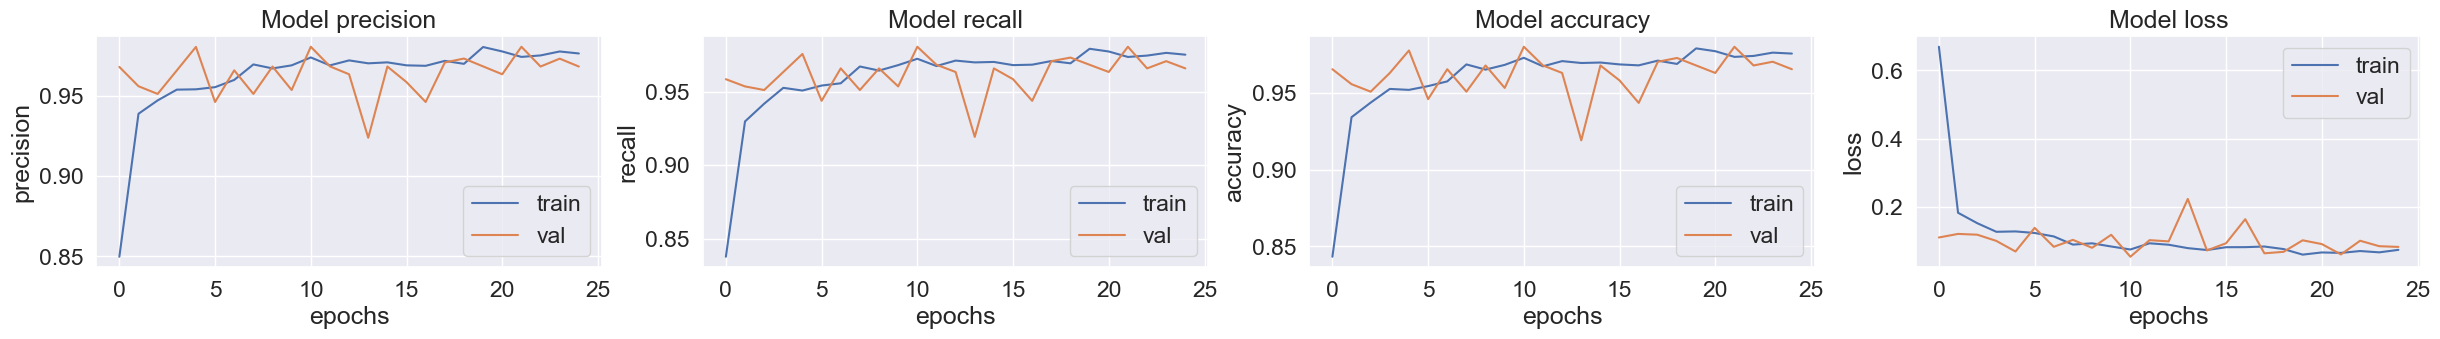

In [36]:
fig, ax = plt.subplots(1, 4, figsize=(30, 3))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall','accuracy',  'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [37]:
preds = model.predict_generator(generator_test)
print(preds)

[[9.99915481e-01 8.44913011e-05 9.17906373e-09 1.06436975e-08]
 [1.69536352e-01 8.30463648e-01 4.42293951e-10 1.32510145e-08]
 [9.85644460e-01 1.43534653e-02 1.86085390e-06 2.87173606e-07]
 ...
 [1.17802083e-04 9.35567081e-01 2.22424005e-05 6.42928705e-02]
 [3.85333635e-07 2.98612463e-07 2.53237182e-08 9.99999285e-01]
 [3.00802640e-05 3.06724178e-06 1.26262762e-06 9.99965549e-01]]


In [38]:
print(classification_report(generator_test.classes, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       118
           1       0.97      0.97      0.97       138
           2       1.00      1.00      1.00       107
           3       1.00      0.98      0.99        42

    accuracy                           0.98       405
   macro avg       0.98      0.98      0.98       405
weighted avg       0.98      0.98      0.98       405



In [39]:
predicted_class_indices=np.argmax(preds,axis=1)
a=0
b=0
for x in predicted_class_indices:
    if x==0:
        a+=1
    else:
        b+=1
print(a," ",b)

119   286


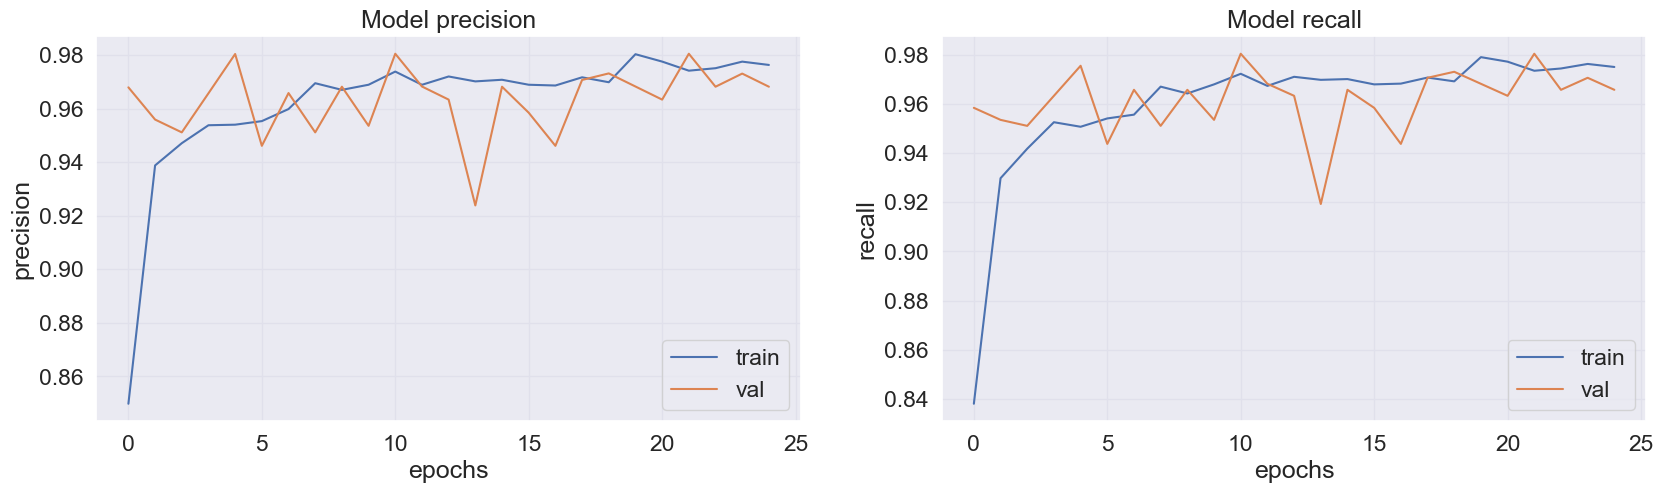

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'])

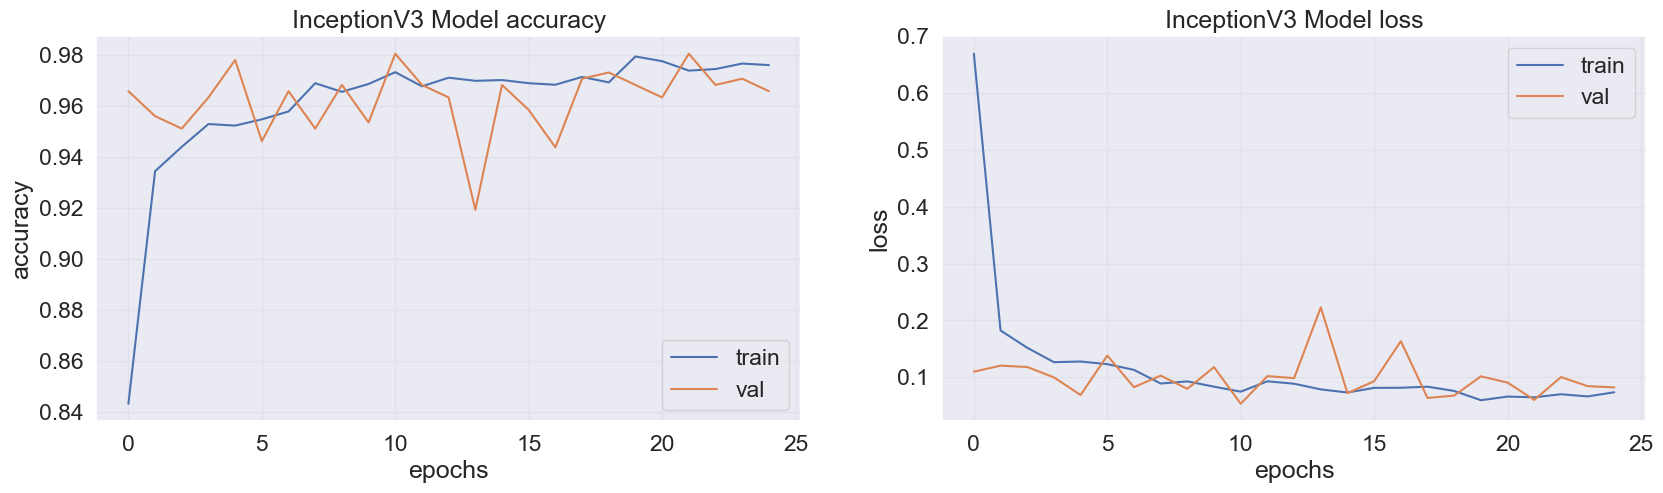

In [42]:

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()
for i, met in enumerate([ 'accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('InceptionV3 Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'],loc='best')
plt.show()

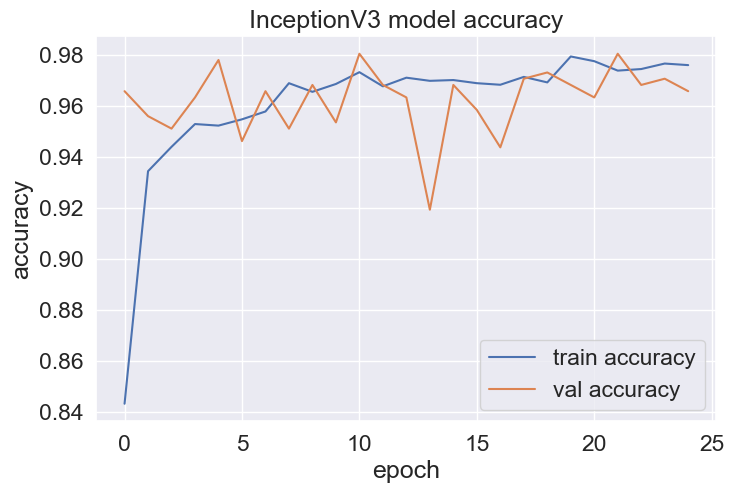

In [43]:

plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history['val_accuracy'],label="val accuracy")
plt.title('InceptionV3 model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('InceptionV3_accuracy',dpi=200); 
plt.show()


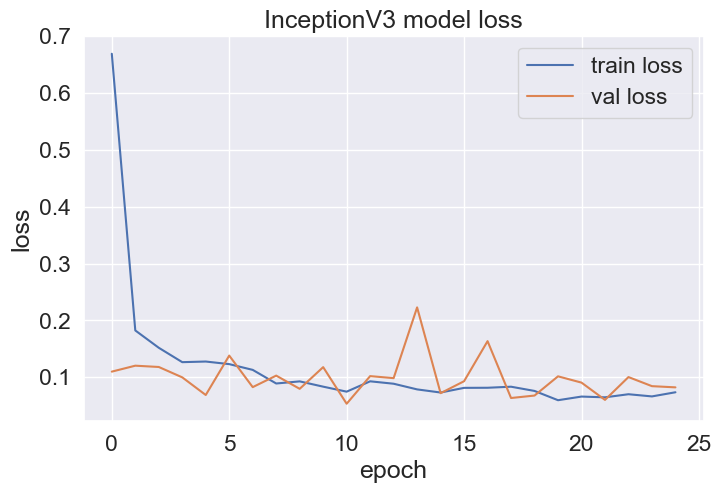

In [44]:
plt.figure(figsize=(8, 5))

ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="val loss")
plt.title('InceptionV3 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('InceptionV3_loss',dpi=200); 
plt.show()